# Human Activity Recognition with Smartphones
## Sequence Model Classification: RNN, LSTM, GRU, BiLSTM, BiGRU

**Dataset:** Human Activity Recognition Using Smartphones  
**Task:** Multiclass Classification (6 aktivitas)  
**Model:** RNN, LSTM, GRU, BiLSTM, BiGRU

---
## 1. Load Data

### 1.1 Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('Libraries imported successfully!')

Libraries imported successfully!


### 1.2 Read Dataset

In [4]:
# Load train dan test set
train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

print(f'Train shape : {train_df.shape}')
print(f'Test  shape : {test_df.shape}')

Train shape : (7352, 563)
Test  shape : (2947, 563)


### 1.3 Preview Data

In [81]:
# Tampilkan 5 baris pertama (hanya kolom awal, kolom akhir, dan label)
preview_cols = list(train_df.columns[:3]) + ['...'] + list(train_df.columns[-3:])
print('Kolom dataset:')
print(preview_cols)
print()
train_df.head()

Kolom dataset:
['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', '...', 'angle(Z,gravityMean)', 'subject', 'Activity']



,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


### 1.4 Info Dataset

In [82]:
print('====== TRAIN INFO ======')
print(f'Jumlah baris   : {train_df.shape[0]}')
print(f'Jumlah kolom   : {train_df.shape[1]}')
print(f'Jumlah fitur   : {train_df.shape[1] - 2}  (561 sensor features)')
print(f'Missing values : {train_df.isnull().sum().sum()}')
print()
print('====== TEST INFO ======')
print(f'Jumlah baris   : {test_df.shape[0]}')
print(f'Jumlah kolom   : {test_df.shape[1]}')
print(f'Missing values : {test_df.isnull().sum().sum()}')

====== TRAIN INFO ======
Jumlah baris   : 7352
Jumlah kolom   : 563
Jumlah fitur   : 561  (561 sensor features)
Missing values : 0

====== TEST INFO ======
Jumlah baris   : 2947
Jumlah kolom   : 563
Missing values : 0


### 1.5 Distribusi Kelas (Activity)

In [83]:
# Hitung distribusi kelas
class_dist_train = train_df['Activity'].value_counts()
class_dist_test  = test_df['Activity'].value_counts()

print('Distribusi Kelas - TRAIN:')
print(class_dist_train.to_string())
print()
print('Distribusi Kelas - TEST:')
print(class_dist_test.to_string())

Distribusi Kelas - TRAIN:
Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986

Distribusi Kelas - TEST:
Activity
LAYING                537
STANDING              532
WALKING               496
SITTING               491
WALKING_UPSTAIRS      471
WALKING_DOWNSTAIRS    420


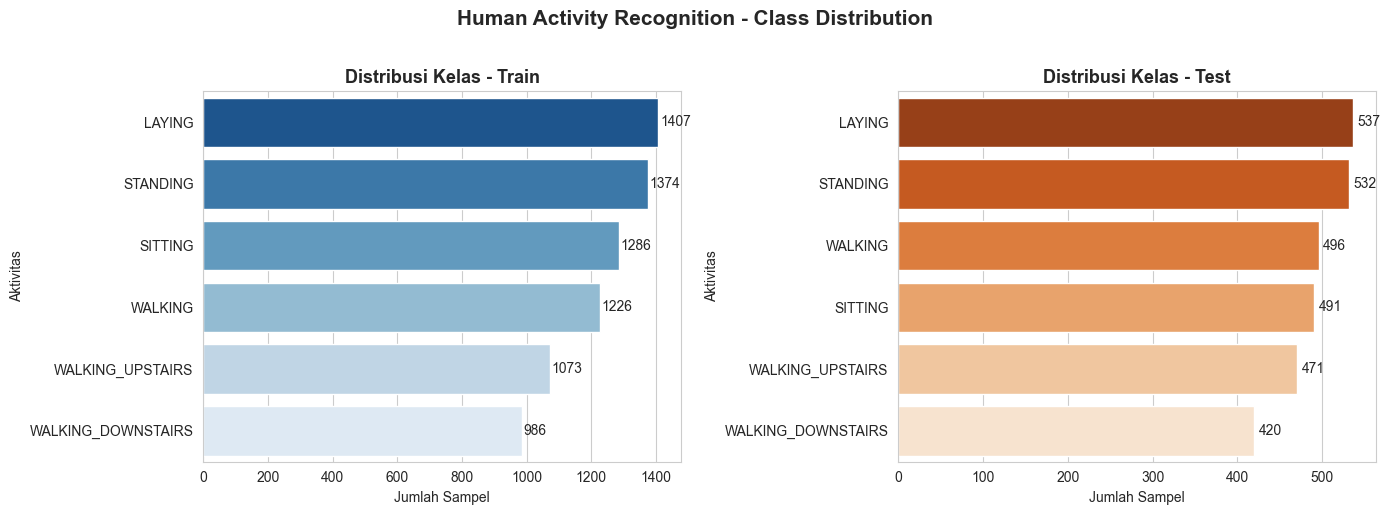

In [84]:
# Visualisasi distribusi kelas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train
sns.barplot(x=class_dist_train.values, y=class_dist_train.index,
            palette='Blues_r', ax=axes[0])
axes[0].set_title('Distribusi Kelas - Train', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jumlah Sampel')
axes[0].set_ylabel('Aktivitas')
for i, v in enumerate(class_dist_train.values):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=10)

# Test
sns.barplot(x=class_dist_test.values, y=class_dist_test.index,
            palette='Oranges_r', ax=axes[1])
axes[1].set_title('Distribusi Kelas - Test', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Jumlah Sampel')
axes[1].set_ylabel('Aktivitas')
for i, v in enumerate(class_dist_test.values):
    axes[1].text(v + 5, i, str(v), va='center', fontsize=10)

plt.suptitle('Human Activity Recognition - Class Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 1.6 Informasi Subjek (Partisipan)

In [85]:
train_subjects = sorted(train_df['subject'].unique())
test_subjects  = sorted(test_df['subject'].unique())

print(f'Jumlah subjek train : {len(train_subjects)}')
print(f'Subjek train        : {train_subjects}')
print()
print(f'Jumlah subjek test  : {len(test_subjects)}')
print(f'Subjek test         : {test_subjects}')
print()

# Pastikan tidak ada overlap subjek antara train dan test (data split by person)
overlap = set(train_subjects) & set(test_subjects)
print(f'Overlap subjek train-test : {overlap if overlap else "Tidak ada (good!)"}')

Jumlah subjek train : 21
Subjek train        : [np.int64(1), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]

Jumlah subjek test  : 9
Subjek test         : [np.int64(2), np.int64(4), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(18), np.int64(20), np.int64(24)]

Overlap subjek train-test : Tidak ada (good!)


### 1.7 Statistik Deskriptif Fitur

In [5]:
# Pisahkan fitur dan label
feature_cols = [col for col in train_df.columns if col not in ['subject', 'Activity']]
print(f'Jumlah fitur sensor : {len(feature_cols)}')
print()

# Statistik deskriptif (5 fitur pertama sebagai contoh)
print('Statistik deskriptif (5 fitur pertama):')
train_df[feature_cols[:5]].describe().round(4)

Jumlah fitur sensor : 561

Statistik deskriptif (5 fitur pertama):


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y
count,7352.0000,7352.0000,7352.0000,7352.0000,7352.0000
mean,0.2745,-0.0177,-0.1091,-0.6054,-0.5109
std,0.0703,0.0408,0.0566,0.4487,0.5026
min,-1.0000,-1.0000,-1.0000,-1.0000,-0.9999
25%,0.2630,-0.0249,-0.1210,-0.9928,-0.9781
50%,0.2772,-0.0172,-0.1087,-0.9462,-0.8519
75%,0.2885,-0.0108,-0.0978,-0.2428,-0.0342
max,1.0000,1.0000,1.0000,1.0000,0.9162


In [87]:
# Ringkasan dataset
print('=' * 50)
print('       RINGKASAN DATASET HAR')
print('=' * 50)
print(f'  Total data train   : {len(train_df):,} sampel')
print(f'  Total data test    : {len(test_df):,} sampel')
print(f'  Jumlah fitur       : {len(feature_cols)} fitur sensor')
print(f'  Jumlah kelas       : {train_df["Activity"].nunique()} aktivitas')
print(f'  Kelas              : {list(train_df["Activity"].unique())}')
print(f'  Jumlah subjek      : {train_df["subject"].nunique() + test_df["subject"].nunique()} orang')
print(f'  Missing values     : Tidak ada')
print('=' * 50)

       RINGKASAN DATASET HAR
  Total data train   : 7,352 sampel
  Total data test    : 2,947 sampel
  Jumlah fitur       : 561 fitur sensor
  Jumlah kelas       : 6 aktivitas
  Kelas              : ['STANDING', 'SITTING', 'LAYING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']
  Jumlah subjek      : 30 orang
  Missing values     : Tidak ada


EDA

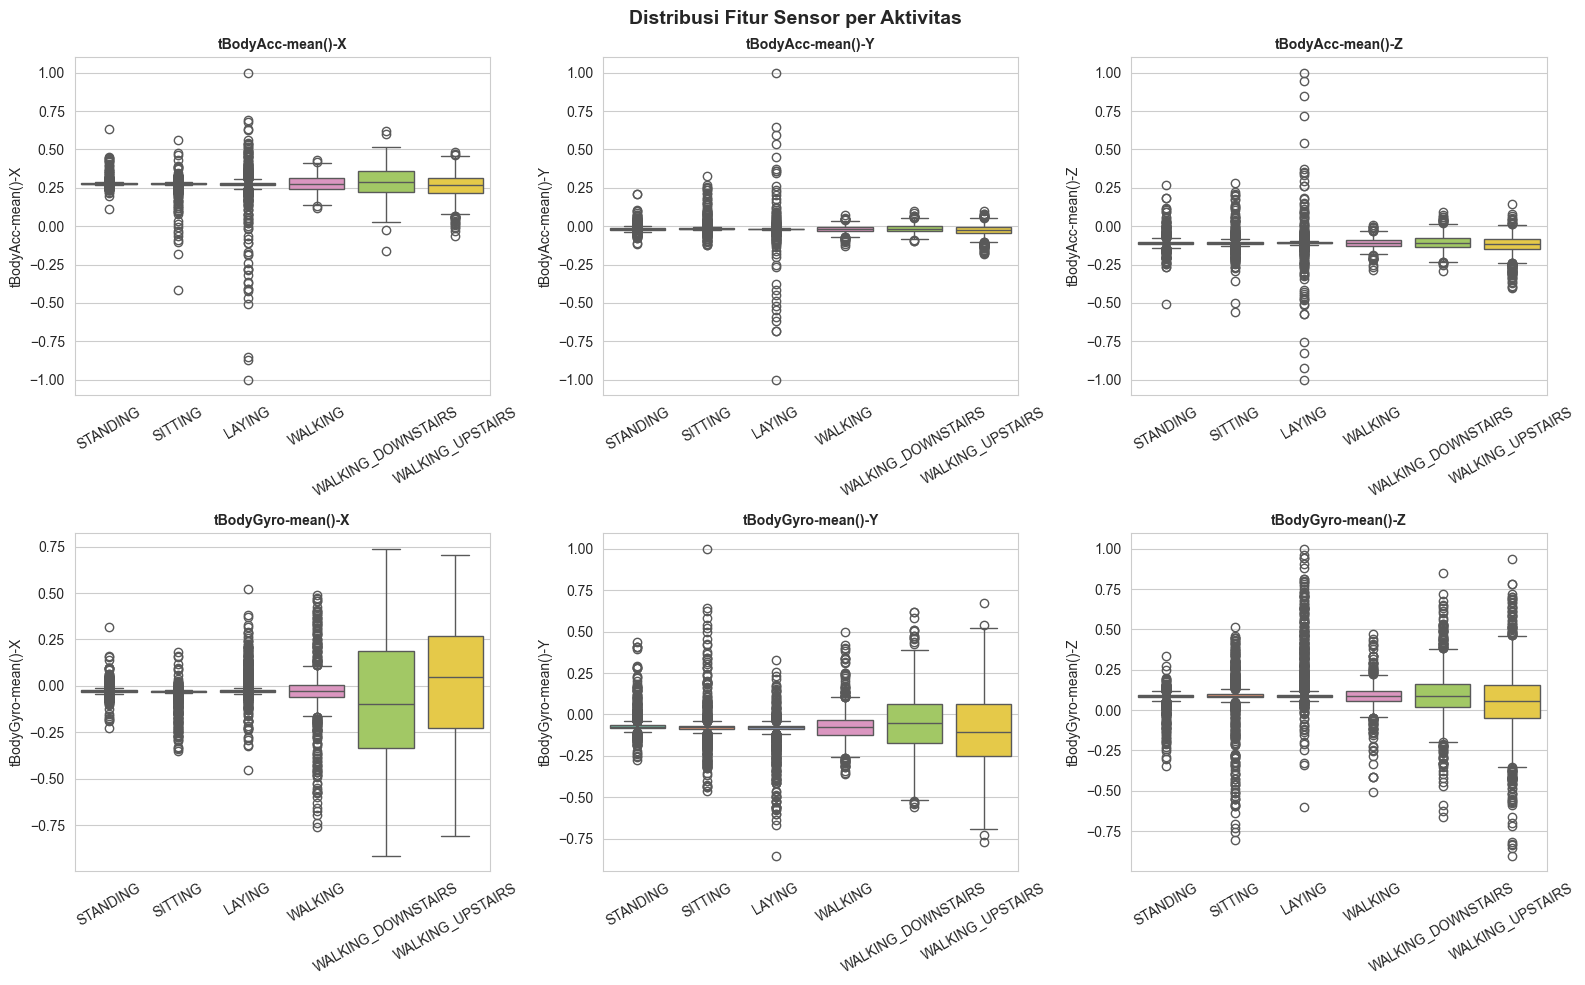

In [88]:
# Visualisasi beberapa fitur sensor penting per aktivitas
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

top_features = [
    'tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z',
    'tBodyGyro-mean()-X', 'tBodyGyro-mean()-Y', 'tBodyGyro-mean()-Z'
]

for i, feat in enumerate(top_features):
    sns.boxplot(data=train_df, x='Activity', y=feat, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{feat}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Distribusi Fitur Sensor per Aktivitas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

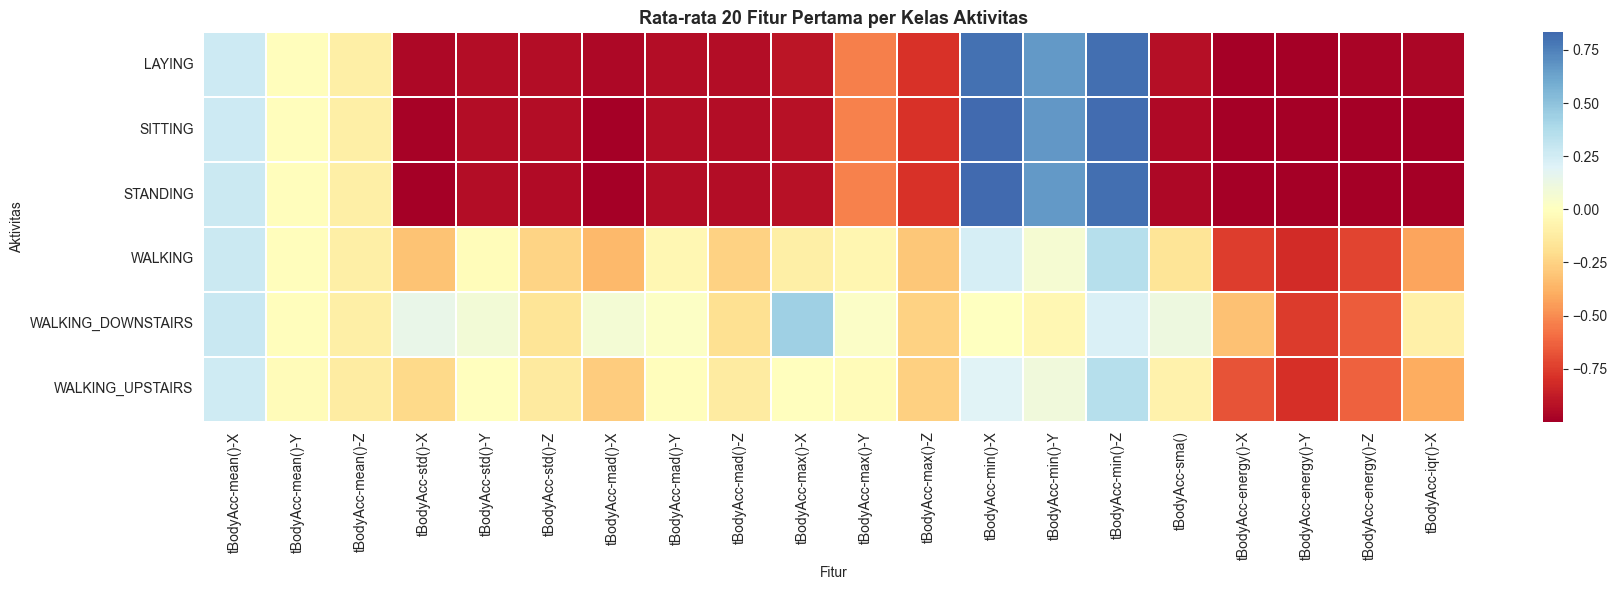

In [89]:
# Heatmap rata-rata 20 fitur pertama per kelas aktivitas
feature_cols = [col for col in train_df.columns if col not in ['subject', 'Activity']]

mean_by_class = train_df.groupby('Activity')[feature_cols[:20]].mean()

plt.figure(figsize=(18, 6))
sns.heatmap(mean_by_class, cmap='RdYlBu', center=0, linewidths=0.3, annot=False)
plt.title('Rata-rata 20 Fitur Pertama per Kelas Aktivitas', fontsize=13, fontweight='bold')
plt.ylabel('Aktivitas')
plt.xlabel('Fitur')
plt.tight_layout()
plt.show()

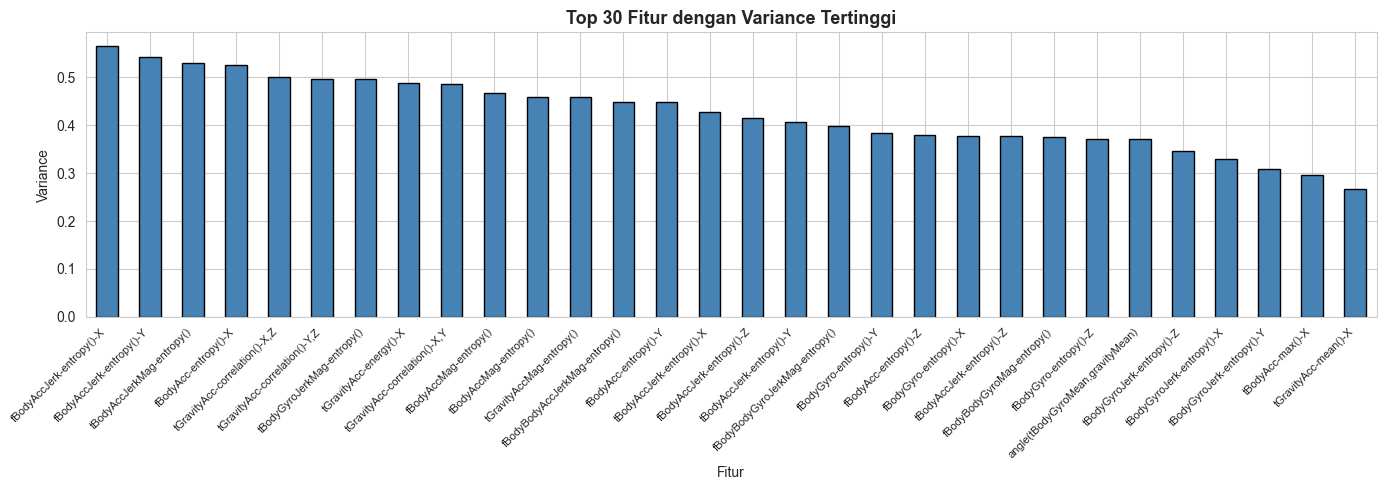

Top 10 fitur paling informatif:
fBodyAccJerk-entropy()-X         0.565102
fBodyAccJerk-entropy()-Y         0.542504
tBodyAccJerkMag-entropy()        0.528914
fBodyAcc-entropy()-X             0.525717
tGravityAcc-correlation()-X,Z    0.500873
tGravityAcc-correlation()-Y,Z    0.495843
tBodyGyroJerkMag-entropy()       0.495160
tGravityAcc-energy()-X           0.487070
tGravityAcc-correlation()-X,Y    0.485302
fBodyAccMag-entropy()            0.466093
dtype: float64


In [7]:
# Cek fitur dengan variance tertinggi (paling informatif)
feat_variance = train_df[feature_cols].var().sort_values(ascending=False)

plt.figure(figsize=(14, 5))
feat_variance.head(30).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 30 Fitur dengan Variance Tertinggi', fontsize=13, fontweight='bold')
plt.xlabel('Fitur')
plt.ylabel('Variance')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

print('Top 10 fitur paling informatif:')
print(feat_variance.head(10))

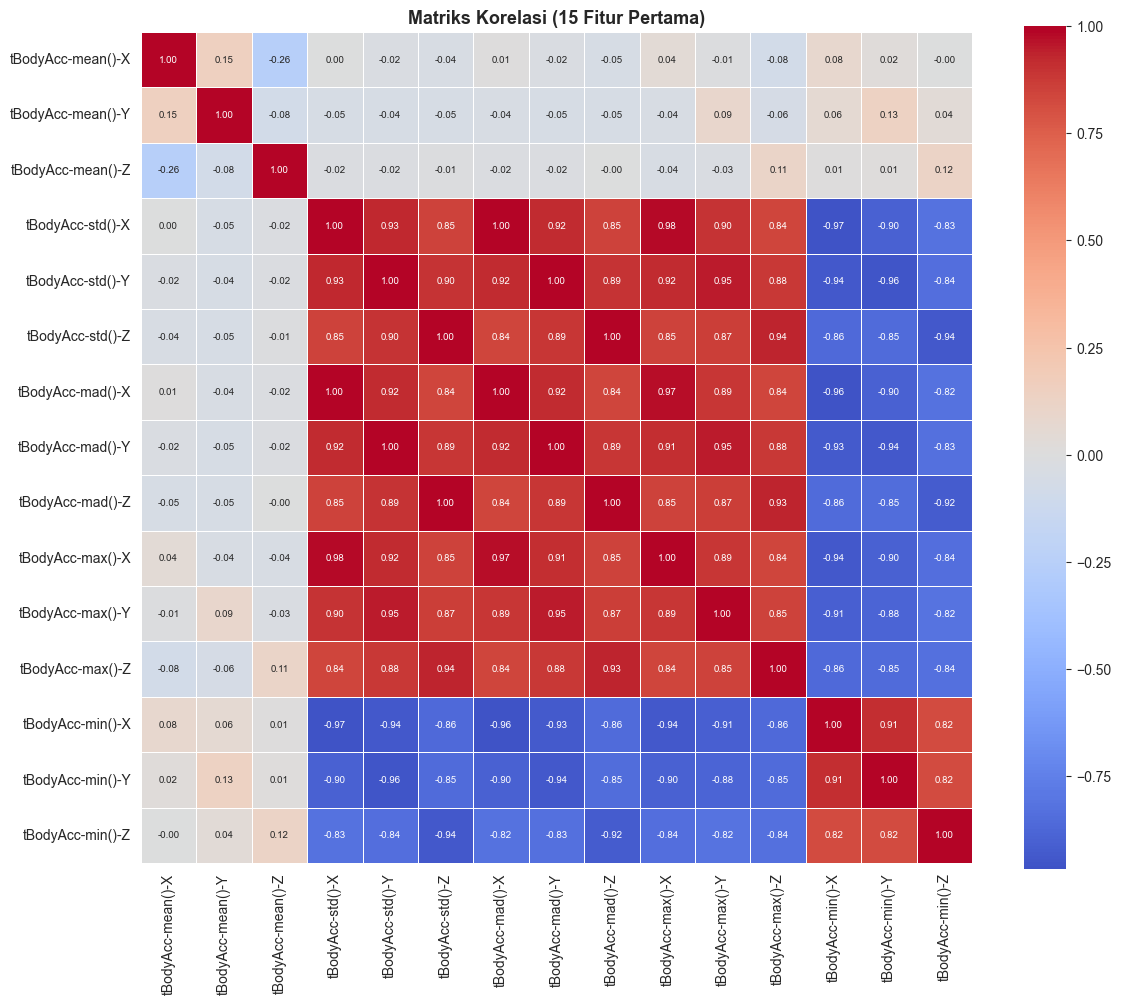

In [91]:
# Korelasi 15 fitur pertama
sample_feats = feature_cols[:15]
corr_matrix = train_df[sample_feats].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, annot_kws={'size': 7})
plt.title('Matriks Korelasi (15 Fitur Pertama)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

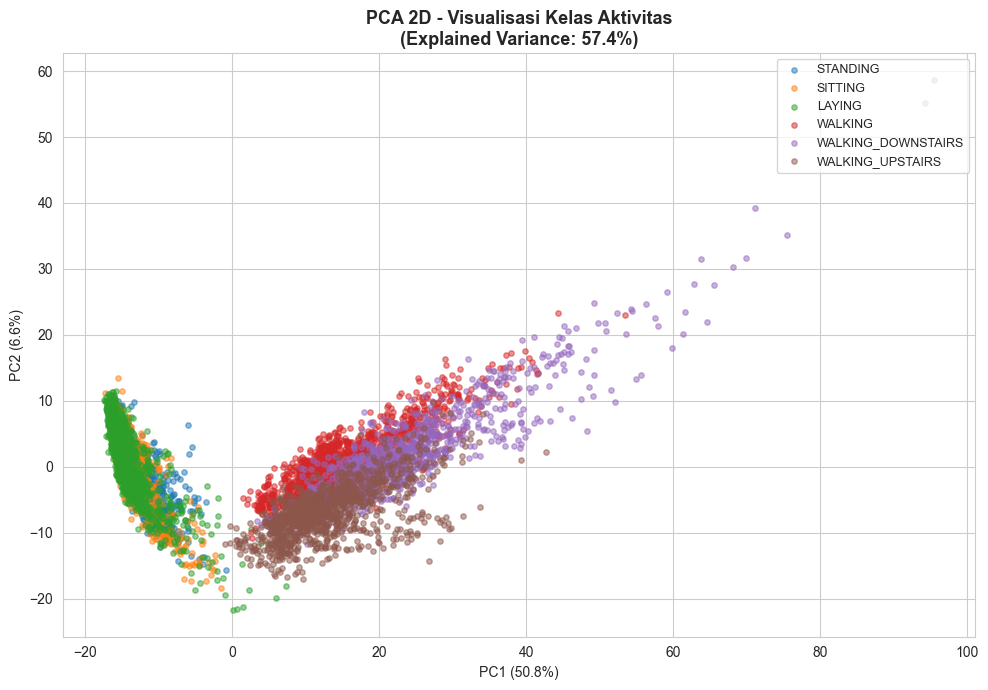

In [92]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

# Scaler & encode
scaler_eda = StandardScaler()
X_scaled = scaler_eda.fit_transform(train_df[feature_cols])

# PCA 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Plot
palette = sns.color_palette('tab10', 6)
activity_labels = train_df['Activity'].values

plt.figure(figsize=(10, 7))
for i, act in enumerate(train_df['Activity'].unique()):
    mask = activity_labels == act
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=act, alpha=0.5, s=15, color=palette[i])

plt.title(f'PCA 2D - Visualisasi Kelas Aktivitas\n(Explained Variance: {pca.explained_variance_ratio_.sum()*100:.1f}%)',
          fontsize=13, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

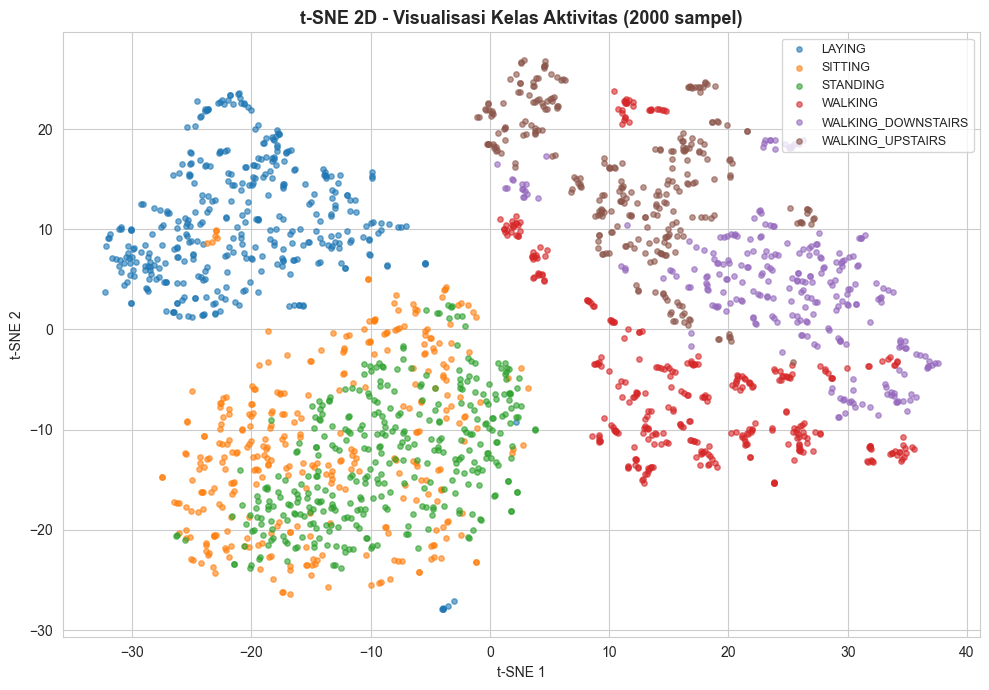

In [93]:
from sklearn.manifold import TSNE

# t-SNE (pakai subset agar cepat)
sample_idx = np.random.choice(len(X_scaled), size=2000, replace=False)
X_sample = X_scaled[sample_idx]
y_sample = activity_labels[sample_idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=500)
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(10, 7))
for i, act in enumerate(np.unique(y_sample)):
    mask = y_sample == act
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                label=act, alpha=0.6, s=15, color=palette[i])

plt.title('t-SNE 2D - Visualisasi Kelas Aktivitas (2000 sampel)',
          fontsize=13, fontweight='bold')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

<Figure size 1600x600 with 0 Axes>

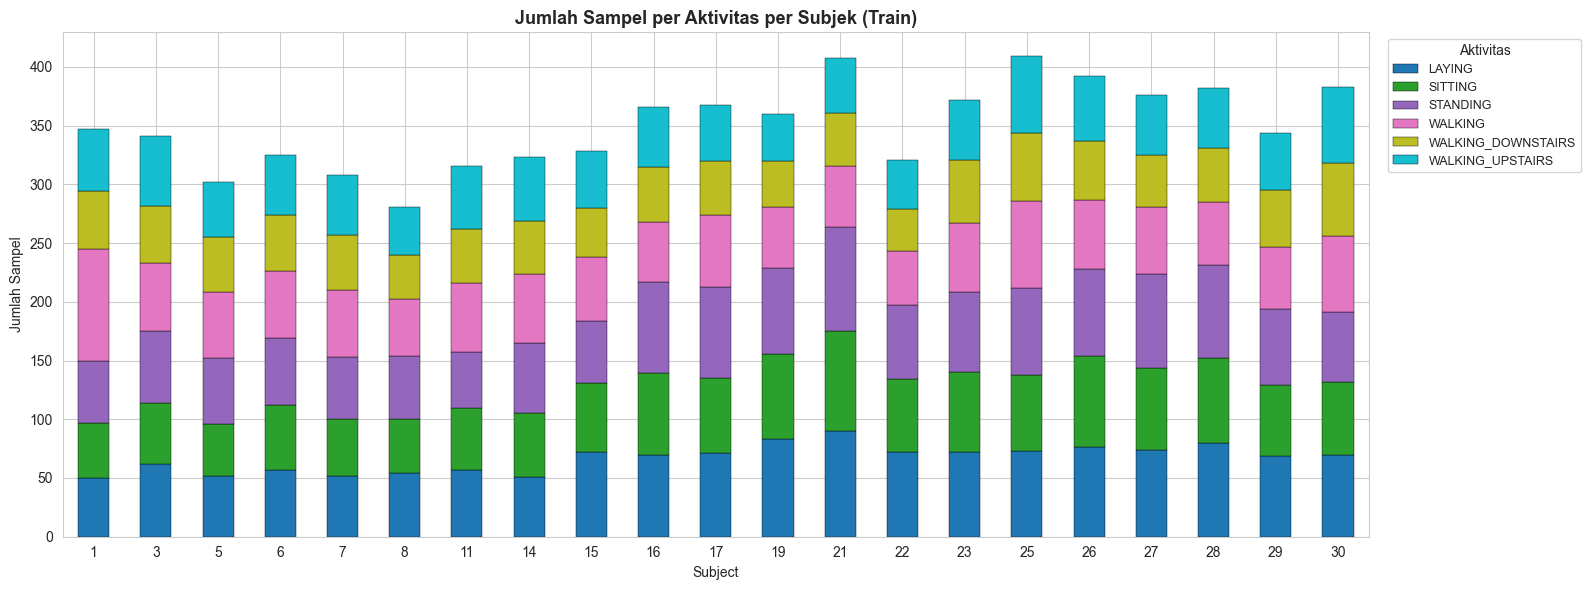

In [94]:
# Jumlah sampel tiap aktivitas per subjek
pivot = train_df.groupby(['subject', 'Activity']).size().unstack(fill_value=0)

plt.figure(figsize=(16, 6))
pivot.plot(kind='bar', stacked=True, colormap='tab10', figsize=(16, 6), edgecolor='black', linewidth=0.3)
plt.title('Jumlah Sampel per Aktivitas per Subjek (Train)', fontsize=13, fontweight='bold')
plt.xlabel('Subject')
plt.ylabel('Jumlah Sampel')
plt.legend(title='Aktivitas', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
# PREPROCESSING DATA
# Berdasarkan hasil EDA, kita akan melakukan preprocessing berikut:
# 1. Standardisasi fitur (karena variance berbeda dan PCA menunjukkan separasi baik)
# 2. Encoding label aktivitas
# 3. Feature selection jika diperlukan (opsional, berdasarkan variance)
# 4. Split data untuk training/validation

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Pisahkan fitur dan label
X_train = train_df[feature_cols]
y_train = train_df['Activity']
X_test = test_df[feature_cols]
y_test = test_df['Activity']

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

# 2. Standardisasi fitur (fit hanya pada train, transform test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('\\nFitur telah distandardisasi (mean=0, std=1)')
print(f'X_train_scaled mean: {X_train_scaled.mean():.6f}')
print(f'X_train_scaled std: {X_train_scaled.std():.6f}')

# 3. Encode label (string -> integer)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print('\\nLabel encoding:')
for i, label in enumerate(le.classes_):
    print(f'{i}: {label}')

# 4. Split train menjadi train/validation (80/20)
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_scaled, y_train_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_train_encoded  # stratified split untuk balance kelas
)

print('\\nFinal split:')
print(f'Train: {X_train_final.shape[0]} samples')
print(f'Validation: {X_val.shape[0]} samples')
print(f'Test: {X_test_scaled.shape[0]} samples')

# 5. Optional: Feature selection berdasarkan variance tertinggi
# Ambil top 100 fitur dengan variance tertinggi (dari EDA)
top_features = feat_variance.head(100).index.tolist()
print(f'\\nTop 100 fitur dengan variance tertinggi: {top_features[:5]}...')

# Jika ingin menggunakan feature selection:
# X_train_selected = X_train_final[:, [feature_cols.index(f) for f in top_features]]
# X_val_selected = X_val[:, [feature_cols.index(f) for f in top_features]]
# X_test_selected = X_test_scaled[:, [feature_cols.index(f) for f in top_features]]

print('\\nPreprocessing selesai! Data siap untuk modeling.')

X_train shape: (7352, 561)
X_test shape: (2947, 561)
y_train shape: (7352,)
y_test shape: (2947,)
\nFitur telah distandardisasi (mean=0, std=1)
X_train_scaled mean: 0.000000
X_train_scaled std: 1.000000
\nLabel encoding:
0: LAYING
1: SITTING
2: STANDING
3: WALKING
4: WALKING_DOWNSTAIRS
5: WALKING_UPSTAIRS
\nFinal split:
Train: 5881 samples
Validation: 1471 samples
Test: 2947 samples
\nTop 100 fitur dengan variance tertinggi: ['fBodyAccJerk-entropy()-X', 'fBodyAccJerk-entropy()-Y', 'tBodyAccJerkMag-entropy()', 'fBodyAcc-entropy()-X', 'tGravityAcc-correlation()-X,Z']...
\nPreprocessing selesai! Data siap untuk modeling.


## 3. Modeling dengan Sequence Models

Berdasarkan preprocessing yang telah dilakukan, sekarang kita akan membuat model klasifikasi menggunakan berbagai arsitektur RNN:

- **RNN (Recurrent Neural Network)**
- **LSTM (Long Short-Term Memory)**  
- **GRU (Gated Recurrent Unit)**
- **BiLSTM (Bidirectional LSTM)**
- **BiGRU (Bidirectional GRU)**

Dataset HAR ini adalah sequence data dari sensor accelerometer dan gyroscope, yang sangat cocok untuk model sequence learning.

In [9]:
# Import PyTorch untuk modeling
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Reshape data untuk sequence input (seq_len=1, features=561)
X_train_tensor = torch.FloatTensor(X_train_final).unsqueeze(1).to(device)  # (batch, 1, 561)
y_train_tensor = torch.LongTensor(y_train_final).to(device)
X_val_tensor = torch.FloatTensor(X_val).unsqueeze(1).to(device)
y_val_tensor = torch.LongTensor(y_val).to(device)
X_test_tensor = torch.FloatTensor(X_test_scaled).unsqueeze(1).to(device)
y_test_tensor = torch.LongTensor(y_test_encoded).to(device)

print(f'X_train_tensor shape: {X_train_tensor.shape}')
print(f'y_train_tensor shape: {y_train_tensor.shape}')

# Create DataLoaders
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'Batch size: {batch_size}')
print(f'Train batches: {len(train_loader)}')
print(f'Val batches: {len(val_loader)}')
print(f'Test batches: {len(test_loader)}')

Using device: cpu
X_train_tensor shape: torch.Size([5881, 1, 561])
y_train_tensor shape: torch.Size([5881])
Batch size: 64
Train batches: 92
Val batches: 23
Test batches: 47


In [10]:
# Define model architectures
class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(RNNModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.rnn(x, h0)
        out = self.fc(out[:, -1, :])  # Take last time step
        return out

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

class BiLSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(BiLSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bilstm = nn.LSTM(input_size, hidden_size, num_layers,
                             batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, num_classes)  # *2 karena bidirectional

    def forward(self, x):
        h0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(device)
        out, _ = self.bilstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

class BiGRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(BiGRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bigru = nn.GRU(input_size, hidden_size, num_layers,
                           batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(device)
        out, _ = self.bigru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

# Model parameters
input_size = X_train_final.shape[1]  # 561 features
hidden_size = 128
num_layers = 2
num_classes = len(le.classes_)  # 6 classes

print(f'Input size: {input_size}')
print(f'Hidden size: {hidden_size}')
print(f'Num layers: {num_layers}')
print(f'Num classes: {num_classes}')

Input size: 561
Hidden size: 128
Num layers: 2
Num classes: 6


In [11]:
# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=50):
    model.to(device)
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss /= len(train_loader)
        train_acc = 100 * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # Validation
        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = 100 * correct / total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

    return train_losses, val_losses, train_accs, val_accs

# Evaluation function
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    return accuracy, all_preds, all_labels

In [12]:
# Initialize models
models = {
    'RNN': RNNModel(input_size, hidden_size, num_layers, num_classes),
    'LSTM': LSTMModel(input_size, hidden_size, num_layers, num_classes),
    'GRU': GRUModel(input_size, hidden_size, num_layers, num_classes),
    'BiLSTM': BiLSTMModel(input_size, hidden_size, num_layers, num_classes),
    'BiGRU': BiGRUModel(input_size, hidden_size, num_layers, num_classes)
}

# Training parameters
learning_rate = 0.001
num_epochs = 50
criterion = nn.CrossEntropyLoss()

# Train all models
results = {}
for model_name, model in models.items():
    print(f'\\n=== Training {model_name} ===')
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses, val_losses, train_accs, val_accs = train_model(
        model, train_loader, val_loader, criterion, optimizer, num_epochs
    )

    # Evaluate on test set
    test_acc, test_preds, test_labels = evaluate_model(model, test_loader)

    results[model_name] = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs,
        'test_acc': test_acc,
        'test_preds': test_preds,
        'test_labels': test_labels
    }

    print(f'{model_name} Test Accuracy: {test_acc:.2f}%')

# Summary results
print('\\n=== FINAL RESULTS ===')
for model_name, result in results.items():
    print(f'{model_name}: Test Acc = {result["test_acc"]:.2f}%')

\n=== Training RNN ===
Epoch [10/50], Train Loss: 0.0154, Train Acc: 99.51%, Val Loss: 0.0468, Val Acc: 98.50%
Epoch [20/50], Train Loss: 0.0068, Train Acc: 99.85%, Val Loss: 0.0457, Val Acc: 98.30%
Epoch [30/50], Train Loss: 0.0002, Train Acc: 100.00%, Val Loss: 0.0451, Val Acc: 99.05%
Epoch [40/50], Train Loss: 0.0001, Train Acc: 100.00%, Val Loss: 0.0457, Val Acc: 98.84%
Epoch [50/50], Train Loss: 0.0000, Train Acc: 100.00%, Val Loss: 0.0493, Val Acc: 98.91%
RNN Test Accuracy: 93.79%
\n=== Training LSTM ===
Epoch [10/50], Train Loss: 0.0162, Train Acc: 99.47%, Val Loss: 0.0383, Val Acc: 98.64%
Epoch [20/50], Train Loss: 0.0009, Train Acc: 99.98%, Val Loss: 0.0443, Val Acc: 98.84%
Epoch [30/50], Train Loss: 0.0002, Train Acc: 100.00%, Val Loss: 0.0440, Val Acc: 98.78%
Epoch [40/50], Train Loss: 0.0001, Train Acc: 100.00%, Val Loss: 0.0448, Val Acc: 98.84%
Epoch [50/50], Train Loss: 0.0000, Train Acc: 100.00%, Val Loss: 0.0468, Val Acc: 98.84%
LSTM Test Accuracy: 94.81%
\n=== Training

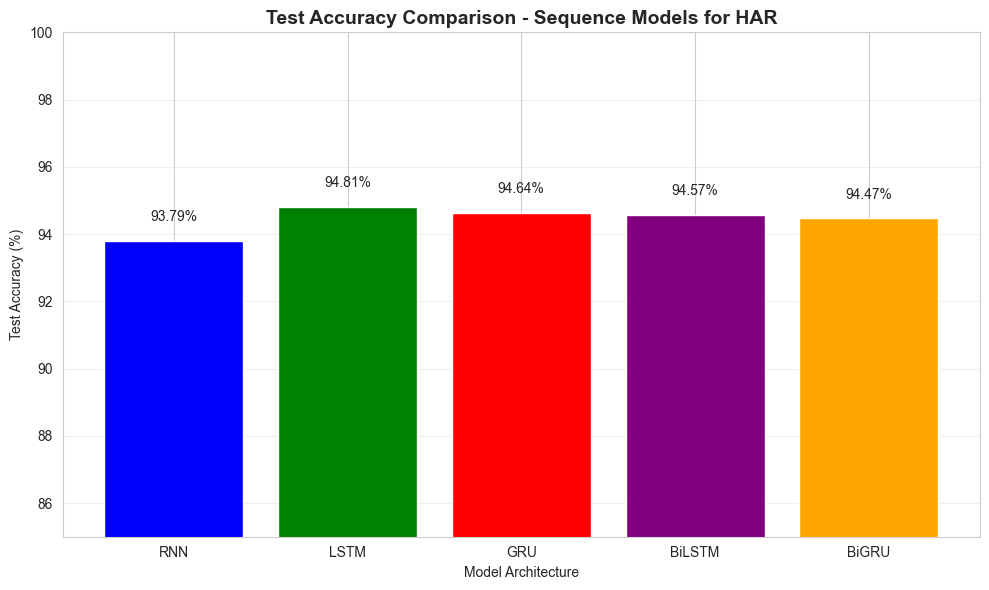

\n=== DETAILED RESULTS ===
\nRNN:
  Final Train Acc: 100.00%
  Final Val Acc: 98.91%
  Test Acc: 93.79%
  Final Train Loss: 0.0000
  Final Val Loss: 0.0493
\nLSTM:
  Final Train Acc: 100.00%
  Final Val Acc: 98.84%
  Test Acc: 94.81%
  Final Train Loss: 0.0000
  Final Val Loss: 0.0468
\nGRU:
  Final Train Acc: 100.00%
  Final Val Acc: 98.91%
  Test Acc: 94.64%
  Final Train Loss: 0.0000
  Final Val Loss: 0.0554
\nBiLSTM:
  Final Train Acc: 100.00%
  Final Val Acc: 99.05%
  Test Acc: 94.57%
  Final Train Loss: 0.0000
  Final Val Loss: 0.0496
\nBiGRU:
  Final Train Acc: 100.00%
  Final Val Acc: 98.98%
  Test Acc: 94.47%
  Final Train Loss: 0.0000
  Final Val Loss: 0.0481
\n=== BEST MODEL ===
Best performing model: LSTM with 94.81% test accuracy


In [13]:
# Visualization of results
import matplotlib.pyplot as plt

model_names = list(results.keys())
test_accuracies = [results[name]['test_acc'] for name in model_names]

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, test_accuracies, color=['blue', 'green', 'red', 'purple', 'orange'])
plt.title('Test Accuracy Comparison - Sequence Models for HAR', fontsize=14, fontweight='bold')
plt.xlabel('Model Architecture')
plt.ylabel('Test Accuracy (%)')
plt.ylim(85, 100)

for bar, acc in zip(bars, test_accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print detailed results
print('\\n=== DETAILED RESULTS ===')
for model_name, result in results.items():
    print(f'\\n{model_name}:')
    print(f'  Final Train Acc: {result["train_accs"][-1]:.2f}%')
    print(f'  Final Val Acc: {result["val_accs"][-1]:.2f}%')
    print(f'  Test Acc: {result["test_acc"]:.2f}%')
    print(f'  Final Train Loss: {result["train_losses"][-1]:.4f}')
    print(f'  Final Val Loss: {result["val_losses"][-1]:.4f}')

print('\\n=== BEST MODEL ===')
best_model = max(results.keys(), key=lambda x: results[x]['test_acc'])
print(f'Best performing model: {best_model} with {results[best_model]["test_acc"]:.2f}% test accuracy')